In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Paths ─────────────────────────────────────────────────────────────────────
GRID_PARQUET_PATH  = "../outputs/grid_assigned.parquet"
GRID_GPKG_PATH     = "../outputs/denmark_grid.gpkg"
ADMIN_GPKG_PATH    = "../outputs/denmark_admin.gpkg"   # for the boundary overlay

In [11]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_parquet(GRID_PARQUET_PATH)
df = df.dropna(subset=["decimalLatitude", "decimalLongitude"])

print(f"Records loaded  : {len(df):,}")
print(f"Unique species  : {df['species'].nunique():,}")

Records loaded  : 30,138,961
Unique species  : 510


In [12]:
# ── Compute species richness per grid cell ────────────────────────────────────
richness = (
    df.groupby("grid_cell_id")["species"]
    .nunique()
    .reset_index()
    .rename(columns={"species": "species_richness"})
)

print(f"Total grid cells with records: {len(richness):,}")
print(f"\nRichness distribution:")
print(richness["species_richness"].describe())

Total grid cells with records: 134

Richness distribution:
count    134.000000
mean     256.111940
std       49.581657
min       16.000000
25%      237.000000
50%      260.500000
75%      285.000000
max      374.000000
Name: species_richness, dtype: float64


In [13]:
# ── Define hotspot threshold ───────────────────────────────────────────────────
TOTAL_SPECIES    = 510
HOTSPOT_FRACTION = 0.60
HOTSPOT_THRESHOLD = TOTAL_SPECIES * HOTSPOT_FRACTION  # = 306

# Any cell with species_richness >= 306 is a hotspot
hotspots    = richness[richness["species_richness"] >= HOTSPOT_THRESHOLD]
non_hotspot = richness[richness["species_richness"] <  HOTSPOT_THRESHOLD]

print(f"Total unique species          : {TOTAL_SPECIES}")
print(f"Hotspot threshold (60%)       : {HOTSPOT_THRESHOLD:.1f} → cells with ≥ 306 species")
print(f"Hotspot cells                 : {len(hotspots):,}")
print(f"Non-hotspot cells with records: {len(non_hotspot):,}")
print(f"\nHotspot richness range: "
      f"{hotspots['species_richness'].min()} – {hotspots['species_richness'].max()}")

Total unique species          : 510
Hotspot threshold (60%)       : 306.0 → cells with ≥ 306 species
Hotspot cells                 : 14
Non-hotspot cells with records: 120

Hotspot richness range: 309 – 374


In [14]:
# ── Load grid geometry and merge richness ─────────────────────────────────────
grid_gdf = gpd.read_file(GRID_GPKG_PATH)

# Merge richness values onto grid geometry
grid_richness = grid_gdf.merge(richness, on="grid_cell_id", how="left")
grid_richness["species_richness"] = grid_richness["species_richness"].fillna(0)

# Create a boolean hotspot flag column for easy filtering
grid_richness["is_hotspot"] = grid_richness["species_richness"] >= HOTSPOT_THRESHOLD

print(f"Grid cells in GeoPackage : {len(grid_gdf):,}")
print(f"Hotspot cells in grid    : {grid_richness['is_hotspot'].sum():,}")

Grid cells in GeoPackage : 134
Hotspot cells in grid    : 14


In [15]:
# ── Load Denmark outline ──────────────────────────────────────────────────────
denmark_outline = gpd.read_file(ADMIN_GPKG_PATH).dissolve()

/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_2244/1086917353.py:54: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


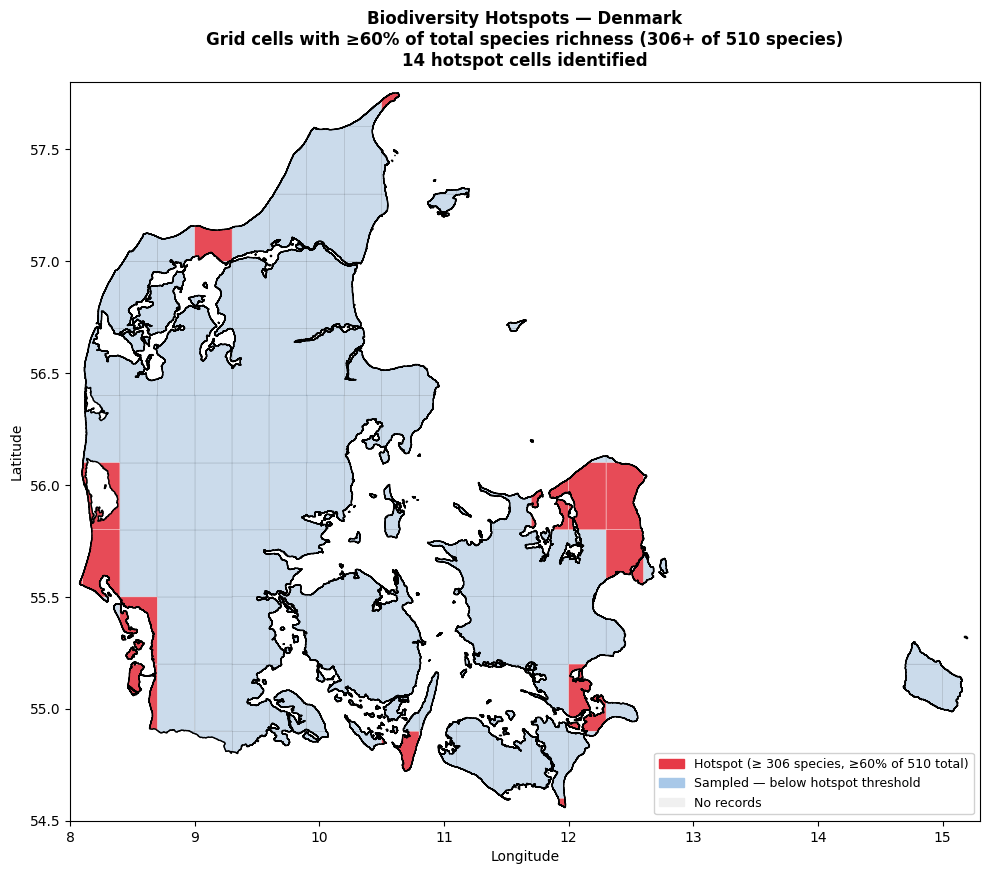

Saved to ../outputs/hotspots_60pct.png


In [16]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

# Layer 1 — Denmark land background
denmark_outline.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.8
)

# Layer 2 — Non-hotspot cells with records (light blue, subtle)
# These give context — you can see where sampling happened
# without these dominating the visual
grid_richness[
    (grid_richness["species_richness"] > 0) &
    (~grid_richness["is_hotspot"])
].plot(
    ax=ax,
    color="#a8c8e8",    # muted blue — present but not the focus
    edgecolor="black",
    linewidth=0.1,
    alpha=0.5
)

# Layer 3 — Hotspot cells (bold red — the main finding)
grid_richness[grid_richness["is_hotspot"]].plot(
    ax=ax,
    color="#e63946",    # strong red — visually dominant
    edgecolor="white",
    linewidth=0.3,
    alpha=0.9
)

# Layer 4 — Denmark outline on top so border is always visible
denmark_outline.plot(
    ax=ax,
    color="none",
    edgecolor="black",
    linewidth=1.0
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(
        color="#e63946",
        label=f"Hotspot (≥ {int(HOTSPOT_THRESHOLD)} species, "
              f"≥60% of {TOTAL_SPECIES} total)"
    ),
    mpatches.Patch(
        color="#a8c8e8",
        label="Sampled — below hotspot threshold"
    ),
    mpatches.Patch(
        color="#f0f0f0",
        edgecolor="black",
        label="No records"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    framealpha=0.9
)

# ── Labels and formatting ─────────────────────────────────────────────────────
ax.set_title(
    f"Biodiversity Hotspots — Denmark\n"
    f"Grid cells with ≥60% of total species richness "
    f"({int(HOTSPOT_THRESHOLD)}+ of {TOTAL_SPECIES} species)\n"
    f"{grid_richness['is_hotspot'].sum()} hotspot cells identified",
    fontsize=12, fontweight="bold", pad=12
)

ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude",  fontsize=10)
ax.set_xlim(8.0,  15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig("../outputs/hotspots_60pct.png", dpi=1500, bbox_inches="tight")
plt.show()

print("Saved to ../outputs/hotspots_60pct.png")

---
## National Parks Overlay
We add Denmark's **5 official national parks** to the hotspot map to visually compare 
whether protected areas coincide with high-richness cells.  
Park boundaries are approximated from official MFVM / SNS shapefiles 
(bounding-box polygons in WGS 84); replace with exact geometries for publication.

In [21]:
from shapely.geometry import box
import geopandas as gpd
import pandas as pd

# ── Denmark national parks — approximate bounding boxes (WGS 84 / EPSG:4326) ──
# Source: Miljøministeriet / SNS park boundaries (simplified for overlay use)
# Columns: name, established, area_km2, minx, miny, maxx, maxy
parks_data = [
    {
        "name"        : "Thy",
        "established" : 2008,
        "area_km2"    : 244,
        "minx": 8.1252, "miny": 56.6663, "maxx": 8.6482, "maxy": 57.1751,
    },
    {
        "name"        : "Vadehavet",
        "established" : 2010,
        "area_km2"    : 1466,   # incl. marine
        "minx": 8.083, "miny": 54.9167, "maxx": 9.0833, "maxy": 55.6167,
    },
    {
        "name"        : "Mols Bjerge",
        "established" : 2009,
        "area_km2"    : 180,
        "minx": 10.3667, "miny": 56.1417, "maxx": 10.7483, "maxy": 56.3333,
    },
    {
        "name"        : "Kongernes\nNordsjælland",
        "established" : 2018,
        "area_km2"    : 220,
        "minx": 11.9500, "miny": 55.8167, "maxx": 12.6000, "maxy": 56.1333,
    },
    {
        "name"        : "Skjoldungernes\nLand",
        "established" : 2015,
        "area_km2"    : 470,
        "minx": 11.8333, "miny": 55.5333, "maxx": 12.1833, "maxy": 55.6833,
    },
]

parks_df = pd.DataFrame(parks_data)
parks_df["geometry"] = parks_df.apply(
    lambda r: box(r["minx"], r["miny"], r["maxx"], r["maxy"]), axis=1
)
parks_gdf = gpd.GeoDataFrame(parks_df, crs="EPSG:4326")

# Centroid for label placement
parks_gdf["cx"] = parks_gdf.geometry.centroid.x
parks_gdf["cy"] = parks_gdf.geometry.centroid.y

print(parks_gdf[["name", "established", "area_km2", "cx", "cy"]])


                      name  established  area_km2        cx       cy
0                      Thy         2008       244   8.38670  56.9207
1                Vadehavet         2010      1466   8.58315  55.2667
2              Mols Bjerge         2009       180  10.55750  56.2375
3  Kongernes\nNordsjælland         2018       220  12.27500  55.9750
4     Skjoldungernes\nLand         2015       470  12.00830  55.6083


/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_2244/2115768088.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  parks_gdf["cx"] = parks_gdf.geometry.centroid.x
/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_2244/2115768088.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  parks_gdf["cy"] = parks_gdf.geometry.centroid.y


/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_2244/2932734263.py:94: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(


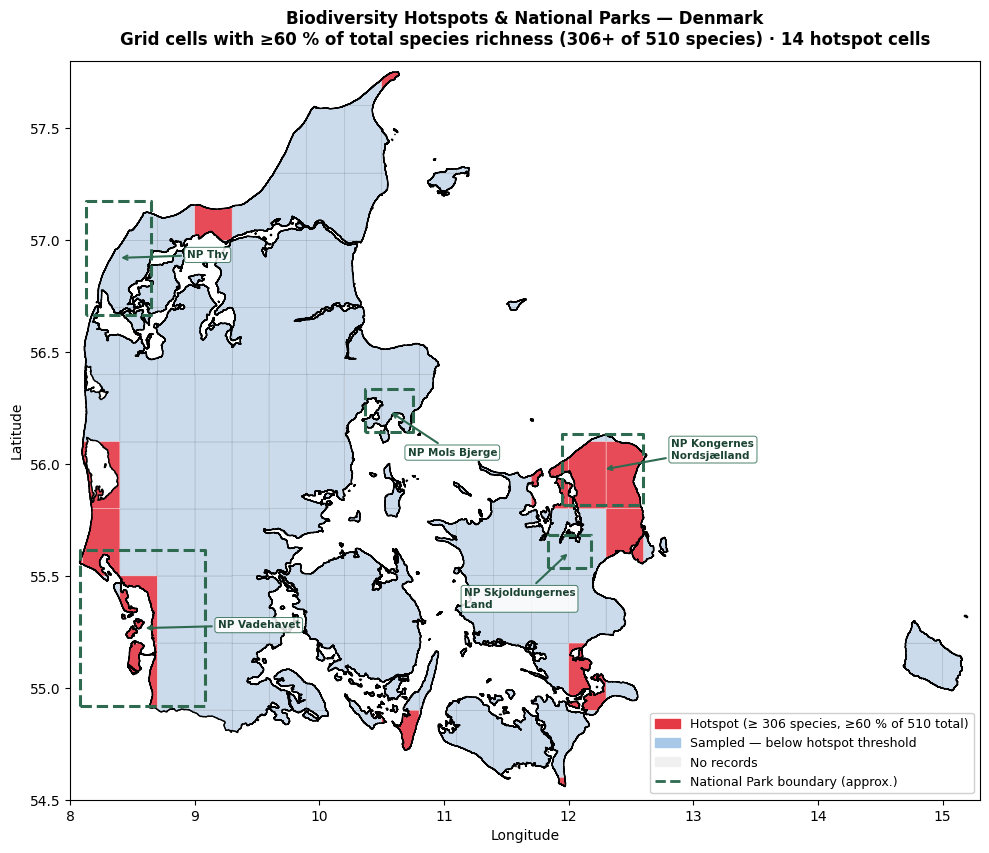

Saved → ../outputs/hotspots_with_national_parks.png


In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 12))

# ── Layer 1 — Denmark land background ────────────────────────────────────────
denmark_outline.plot(
    ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.8
)

# ── Layer 2 — Sampled, non-hotspot cells ─────────────────────────────────────
grid_richness[
    (grid_richness["species_richness"] > 0) &
    (~grid_richness["is_hotspot"])
].plot(
    ax=ax, color="#a8c8e8", edgecolor="black",
    linewidth=0.1, alpha=0.5
)

# ── Layer 3 — Hotspot cells ───────────────────────────────────────────────────
grid_richness[grid_richness["is_hotspot"]].plot(
    ax=ax, color="#e63946", edgecolor="white",
    linewidth=0.3, alpha=0.9
)

# ── Layer 4 — National park boundaries ───────────────────────────────────────
parks_gdf.plot(
    ax=ax,
    color="none",           # transparent fill — show what's underneath
    edgecolor="#2d6a4f",    # forest green outline
    linewidth=2.2,
    linestyle="--",
    zorder=5,
)

# ── Layer 5 — Park name labels ────────────────────────────────────────────────
label_offsets = {
    "Thy"                    : ( 0.55,  0.00),   # push right — avoids coast
    "Vadehavet"              : ( 0.60,  0.00),
    "Mols Bjerge"            : ( 0.15, -0.20),
    "Kongernes\nNordsjælland": ( 0.55,  0.05),
    "Skjoldungernes\nLand"   : (-0.85,  -0.25),   # push left — avoids overlap
}

for _, row in parks_gdf.iterrows():
    dx, dy = label_offsets.get(row["name"], (0.05, 0.05))
    ax.annotate(
        f"NP {row['name']}",
        xy=(row["cx"], row["cy"]),
        xytext=(row["cx"] + dx, row["cy"] + dy),
        fontsize=7.5,
        fontweight="bold",
        color="#1b4332",
        ha="left",
        arrowprops=dict(
            arrowstyle="->",
            color="#2d6a4f",
            lw=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="#2d6a4f",
            alpha=0.85,
            lw=0.7,
        ),
        zorder=6,
    )

# ── Layer 6 — Denmark outline on top ─────────────────────────────────────────
denmark_outline.plot(
    ax=ax, color="none", edgecolor="black", linewidth=1.0
)

# ── Legend ────────────────────────────────────────────────────────────────────
park_patch = mlines.Line2D(
    [], [],
    color="#2d6a4f",
    linewidth=2.0,
    linestyle="--",
    label="National Park boundary (approx.)",
)
legend_handles = [
    mpatches.Patch(
        color="#e63946",
        label=f"Hotspot (≥ {int(HOTSPOT_THRESHOLD)} species, "
              f"≥60 % of {TOTAL_SPECIES} total)",
    ),
    mpatches.Patch(
        color="#a8c8e8",
        label="Sampled — below hotspot threshold",
    ),
    mpatches.Patch(
        color="#f0f0f0",
        edgecolor="black",
        label="No records",
    ),
    park_patch,
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=9,
    framealpha=0.92,
)

# ── Title and axes ────────────────────────────────────────────────────────────
ax.set_title(
    f"Biodiversity Hotspots & National Parks — Denmark\n"
    f"Grid cells with ≥60 % of total species richness "
    f"({int(HOTSPOT_THRESHOLD)}+ of {TOTAL_SPECIES} species) · "
    f"{grid_richness['is_hotspot'].sum()} hotspot cells",
    fontsize=12, fontweight="bold", pad=12,
)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude",  fontsize=10)
ax.set_xlim(8.0, 15.3)
ax.set_ylim(54.5, 57.8)

plt.tight_layout()
plt.savefig(
    "../outputs/hotspots_with_national_parks.png",
    dpi=1600, bbox_inches="tight",
)
plt.show()
print("Saved → ../outputs/hotspots_with_national_parks.png")


In [34]:
# ── Spatial join: which hotspot cells fall inside a national park? ─────────────
hotspot_gdf = grid_richness[grid_richness["is_hotspot"]].copy()

# Use centroids for a clean point-in-polygon join
hotspot_gdf = hotspot_gdf.copy()
hotspot_gdf["geometry"] = hotspot_gdf.geometry.centroid

joined = gpd.sjoin(
    hotspot_gdf,
    parks_gdf[["name", "geometry"]],
    how="left",
    predicate="within",
)

inside_park  = joined[joined["name"].notna()]
outside_park = joined[joined["name"].isna()]

print("=" * 52)
print("Hotspot ↔ National Park overlap summary")
print("=" * 52)
print(f"Total hotspot cells          : {len(hotspot_gdf)}")
print(f"  Inside a national park     : {len(inside_park)}  "
      f"({100*len(inside_park)/len(hotspot_gdf):.1f} %)")
print(f"  Outside all national parks : {len(outside_park)}  "
      f"({100*len(outside_park)/len(hotspot_gdf):.1f} %)")
print()
print("Hotspot cells per park:")
print(inside_park.groupby("name")["species_richness"]
      .agg(["count", "min", "max", "mean"])
      .rename(columns={"count":"cells","min":"min_sp",
                        "max":"max_sp","mean":"avg_sp"})
      .round(1)
      .to_string())
print()
print("Interpretation hints:")
print("  • Parks with many hotspot cells → protection aligns with biodiversity peaks.")
print("  • Hotspots outside all parks  → potential gaps in the protected-area network.")
print("  • Parks with zero hotspot cells → lower richness or sampling bias in that region.")


Hotspot ↔ National Park overlap summary
Total hotspot cells          : 14
  Inside a national park     : 5  (35.7 %)
  Outside all national parks : 9  (64.3 %)

Hotspot cells per park:
                         cells  min_sp  max_sp  avg_sp
name                                                  
Kongernes\nNordsjælland      2     313     315   314.0
Vadehavet                    3     323     360   336.3

Interpretation hints:
  • Parks with many hotspot cells → protection aligns with biodiversity peaks.
  • Hotspots outside all parks  → potential gaps in the protected-area network.
  • Parks with zero hotspot cells → lower richness or sampling bias in that region.


/var/folders/bq/wvw1r1955ld8nc25n3l95m8m0000gn/T/ipykernel_2244/3321191212.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["geometry"] = hotspot_gdf.geometry.centroid
